# 01 - SinOCR Dataset Analysis

Explore the SinOCR dataset: handwritten and printed Sinhala OCR images.
- Sample counts and distributions
- Text length statistics
- Character frequency analysis
- Sample image visualization

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from collections import Counter

sns.set_theme(style='whitegrid')

DATA_ROOT = Path('../../allData')

In [2]:
# Load handwritten data
hw_train = pd.read_csv(DATA_ROOT / 'handwritten-data/train/data.csv')
hw_test = pd.read_csv(DATA_ROOT / 'handwritten-data/test/data.csv')

print(f'Handwritten train: {len(hw_train)} samples')
print(f'Handwritten test:  {len(hw_test)} samples')
print()
hw_train.head()

Handwritten train: 908 samples
Handwritten test:  227 samples



,file_name,text
0,image_0,පුරුෂ
1,image_10,නීල් රූපසිංහ
2,image_100,සහෝදරයා
3,image_1002,පෙරේරලාගේ සමන් කුමාර පීරිස්
4,image_1003,පී . සමන් කුමාර පීරිස්


In [3]:
# Load printed data
pr_train = pd.read_csv(DATA_ROOT / 'printed-data/train/gt.csv')
pr_test = pd.read_csv(DATA_ROOT / 'printed-data/test/gt.csv')

print(f'Printed train: {len(pr_train)} samples')
print(f'Printed test:  {len(pr_test)} samples')
print()
pr_train.head()

Printed train: 90000 samples
Printed test:  10000 samples



,file_name,text
0,b9e76840-0c67-4a73-8bb2-d0100ebb6e92,දෙන්නගෙම වෙළෙඳ ආයතනයයි දෙරණ වැඩසටහන් සජීවී ගුව...
1,4c3b6164-ded1-4fe3-a5e7-eb80e2071220,ඔබගේ පවුලේ අයත් පදිංචි නාවලම නේද
2,25ccea91-545f-453f-850d-38c74c4dcc9d,ඔව් ගාමින්ද ජීවත්වන නාවලමයි අපිත් ඉන්නේ බිරිය ...
3,36478d06-5716-4d47-b95b-3c6b8a6ff969,ඔහු මට හමුවන්නේ තරුණ සේවා සභාවේ රූපවාහිනී වැඩස...
4,8ca6065c-add1-49ab-ad2a-8219f657f1e8,ඔහු ඉතා දක්ෂයි ගාමින්ද රේසින් කාර් තරගයක් බලන්...


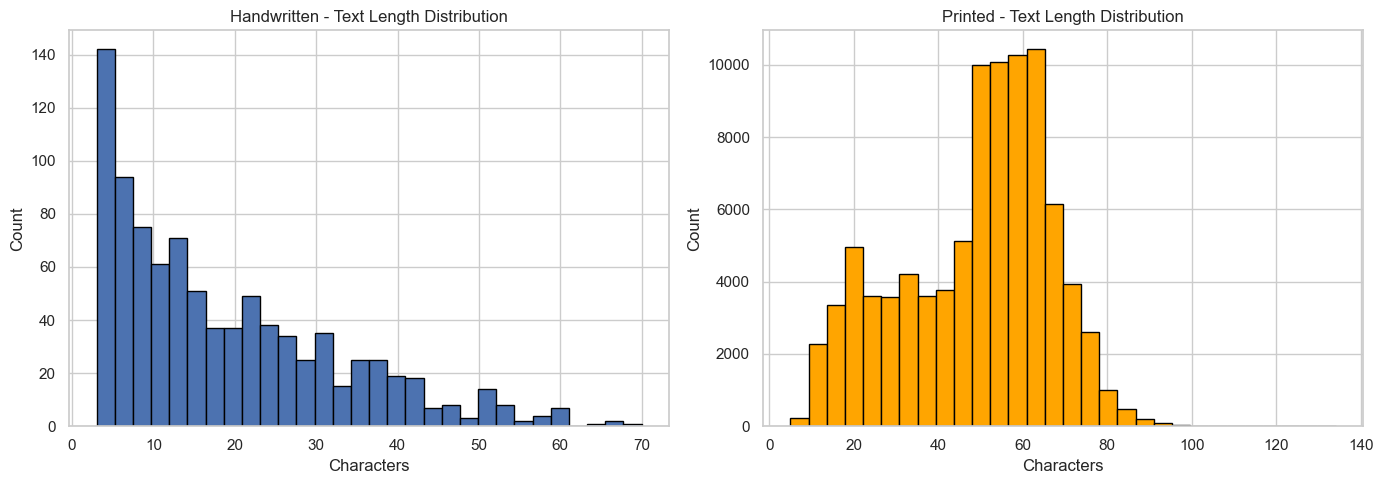

In [4]:
# Text length distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hw_train['text_len'] = hw_train['text'].astype(str).apply(len)
axes[0].hist(hw_train['text_len'], bins=30, edgecolor='black')
axes[0].set_title('Handwritten - Text Length Distribution')
axes[0].set_xlabel('Characters')
axes[0].set_ylabel('Count')

pr_train['text_len'] = pr_train['text'].astype(str).apply(len)
axes[1].hist(pr_train['text_len'], bins=30, edgecolor='black', color='orange')
axes[1].set_title('Printed - Text Length Distribution')
axes[1].set_xlabel('Characters')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

Unique characters in handwritten train: 104



/var/folders/9y/7l0nnld17bg_ksngsz6fyczc0000gn/T/ipykernel_10252/2311723130.py:18: UserWarning: Glyph 3530 (\N{SINHALA SIGN AL-LAKUNA}) missing from current font.
  plt.tight_layout()
/var/folders/9y/7l0nnld17bg_ksngsz6fyczc0000gn/T/ipykernel_10252/2311723130.py:18: UserWarning: Matplotlib currently does not support Sinhala natively.
  plt.tight_layout()
/var/folders/9y/7l0nnld17bg_ksngsz6fyczc0000gn/T/ipykernel_10252/2311723130.py:18: UserWarning: Glyph 3538 (\N{SINHALA VOWEL SIGN KETTI IS-PILLA}) missing from current font.
  plt.tight_layout()
/var/folders/9y/7l0nnld17bg_ksngsz6fyczc0000gn/T/ipykernel_10252/2311723130.py:18: UserWarning: Glyph 3515 (\N{SINHALA LETTER RAYANNA}) missing from current font.
  plt.tight_layout()
/var/folders/9y/7l0nnld17bg_ksngsz6fyczc0000gn/T/ipykernel_10252/2311723130.py:18: UserWarning: Glyph 3505 (\N{SINHALA LETTER DANTAJA NAYANNA}) missing from current font.
  plt.tight_layout()
/var/folders/9y/7l0nnld17bg_ksngsz6fyczc0000gn/T/ipykernel_10252/2311723

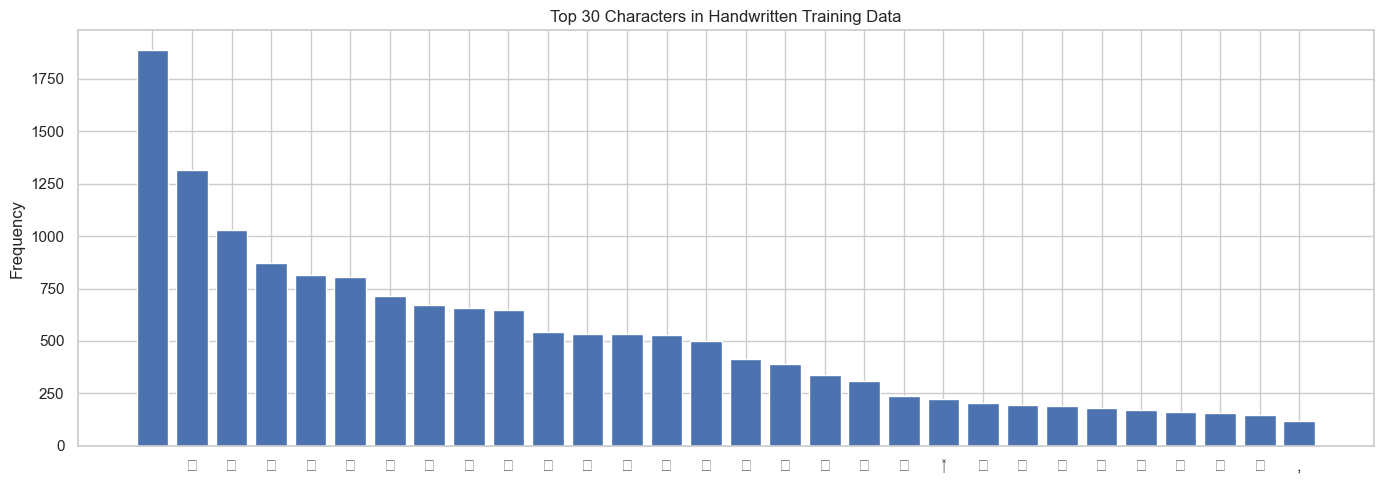

In [5]:
# Character frequency analysis (handwritten)
all_chars = Counter()
for text in hw_train['text'].astype(str):
    all_chars.update(text)

print(f'Unique characters in handwritten train: {len(all_chars)}')
print()

top_30 = all_chars.most_common(30)
chars, counts = zip(*top_30)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(range(len(chars)), counts)
ax.set_xticks(range(len(chars)))
ax.set_xticklabels(chars, fontsize=12)
ax.set_title('Top 30 Characters in Handwritten Training Data')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

/var/folders/9y/7l0nnld17bg_ksngsz6fyczc0000gn/T/ipykernel_10252/1507718181.py:15: UserWarning: Glyph 3508 (\N{SINHALA LETTER ALPAPRAANA PAYANNA}) missing from current font.
  plt.tight_layout()
/var/folders/9y/7l0nnld17bg_ksngsz6fyczc0000gn/T/ipykernel_10252/1507718181.py:15: UserWarning: Matplotlib currently does not support Sinhala natively.
  plt.tight_layout()
/var/folders/9y/7l0nnld17bg_ksngsz6fyczc0000gn/T/ipykernel_10252/1507718181.py:15: UserWarning: Glyph 3540 (\N{SINHALA VOWEL SIGN KETTI PAA-PILLA}) missing from current font.
  plt.tight_layout()
/var/folders/9y/7l0nnld17bg_ksngsz6fyczc0000gn/T/ipykernel_10252/1507718181.py:15: UserWarning: Glyph 3515 (\N{SINHALA LETTER RAYANNA}) missing from current font.
  plt.tight_layout()
/var/folders/9y/7l0nnld17bg_ksngsz6fyczc0000gn/T/ipykernel_10252/1507718181.py:15: UserWarning: Glyph 3522 (\N{SINHALA LETTER MUURDHAJA SAYANNA}) missing from current font.
  plt.tight_layout()
/var/folders/9y/7l0nnld17bg_ksngsz6fyczc0000gn/T/ipykernel

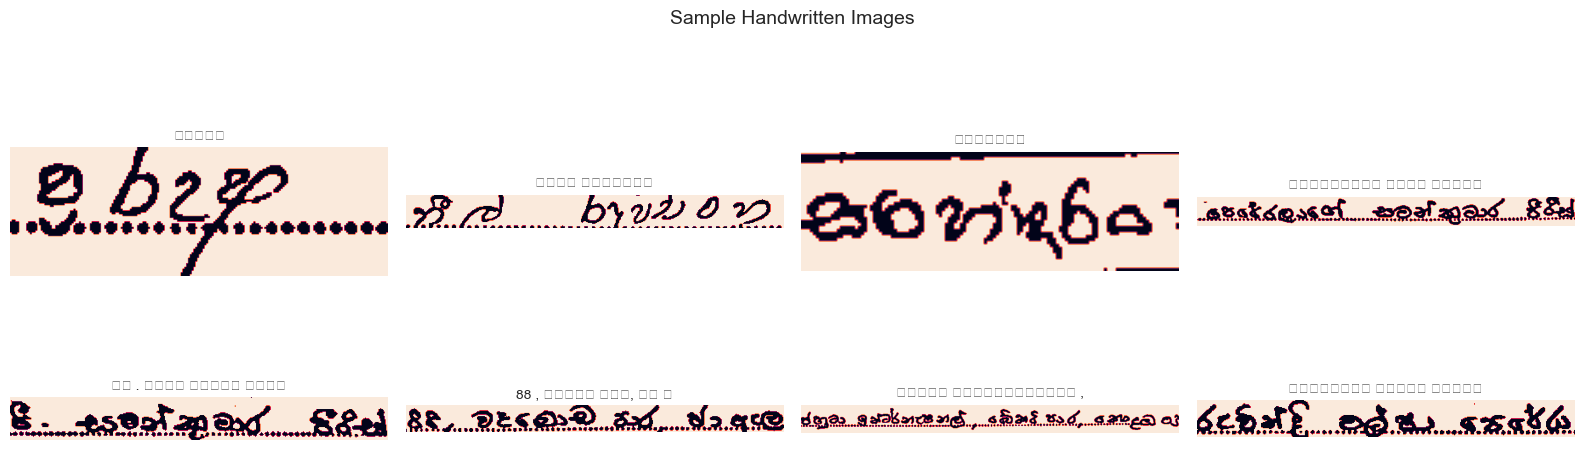

In [6]:
# Visualize sample images
hw_images_dir = DATA_ROOT / 'handwritten-data/train/images'

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for idx, (ax, (_, row)) in enumerate(zip(axes.flat, hw_train.head(8).iterrows())):
    fname = str(row['file_name'])
    if not fname.endswith('.png'):
        fname += '.png'
    img = Image.open(hw_images_dir / fname)
    ax.imshow(img)
    ax.set_title(row['text'][:20], fontsize=10)
    ax.axis('off')

plt.suptitle('Sample Handwritten Images', fontsize=14)
plt.tight_layout()
plt.show()